# Exploratory Data Analysis: Satellite Imagery for Disaster Response

### Dataset Description
Labels are based on the level of damage sustained:
- **0**: No damage
- **1**: Minor damage
- **2**: Major damage
- **3**: Destroyed

The dataset includes three disaster types:
1. **Hurricane Matthew** - Used for damage level classification
2. **Midwest Flooding** - Used for disaster type classification
3. **SoCal Fire** - Used for disaster type classification

## Setup and Data Loading

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

DISASTER_COLORS = {'hurricane-matthew': '#1f77b4',
                    'midwest-flooding': '#2ca02c',
                    'socal-fire': '#d62728'
                    }
# hurricane-matthew - blue, midwest-flooding - green, socal-fire - red

DAMAGE_COLORS = {
    0: '#2ecc71',
    1: '#f1c40f',
    2: '#e67e22',
    3: '#e74c3c'
}
# 0 - green, 1 - yellow, 2 - orange, 3 - red

In [24]:
from load import run

disaster_list = ["hurricane-matthew", "midwest-flooding", "socal-fire"]
data = run(disaster_list)

Loading train images and labels for hurricane-matthew dataset...
Loading train images and labels for midwest-flooding dataset...
Loading train images and labels for socal-fire dataset...


## Data Sampling and Basic Cleaning

In [29]:
quality_report = []

for disaster in disaster_list:
    images = data[disaster]['images']
    labels = data[disaster]['labels']
        
    shapes = [img.shape if img is not None else None for img in images]
    
    channels = [s[2] if s is not None and len(s) == 3 else None for s in shapes]
    unique_channels = set(c for c in channels if c is not None)
    
    quality_report.append({
        'Disaster': disaster,
        'Total Images': len(images),
        'Channels': list(unique_channels)
    })
    
    print(f"\n{disaster.upper()}:")
    print(f"  Total images: {len(images)}")
    print(f"  Sample shape: {images[0].shape if images[0] is not None else 'N/A'}")

quality_df = pd.DataFrame(quality_report)
display(quality_df)


HURRICANE-MATTHEW:
  Total images: 200
  Sample shape: (1024, 1024, 3)

MIDWEST-FLOODING:
  Total images: 200
  Sample shape: (1024, 1024, 3)

SOCAL-FIRE:
  Total images: 200
  Sample shape: (1024, 1024, 3)


,Disaster,Total Images,Channels
0,hurricane-matthew,200,[3]
1,midwest-flooding,200,[3]
2,socal-fire,200,[3]


In [30]:
summary_data = []

for disaster in disaster_list:
    images = data[disaster]['images']
    labels = data[disaster]['labels']
    
    label_counts = Counter(labels)
    
    summary_data.append({
        'Disaster': disaster,
        'Total Images': len(images),
        'Damage 0 (None)': label_counts.get(0, 0),
        'Damage 1 (Minor)': label_counts.get(1, 0),
        'Damage 2 (Major)': label_counts.get(2, 0),
        'Damage 3 (Destroyed)': label_counts.get(3, 0)
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Disaster,Total Images,Damage 0 (None),Damage 1 (Minor),Damage 2 (Major),Damage 3 (Destroyed)
0,hurricane-matthew,200,31,70,6,93
1,midwest-flooding,200,155,6,6,33
2,socal-fire,200,64,2,1,133


## Damage Label Distribution Analysis

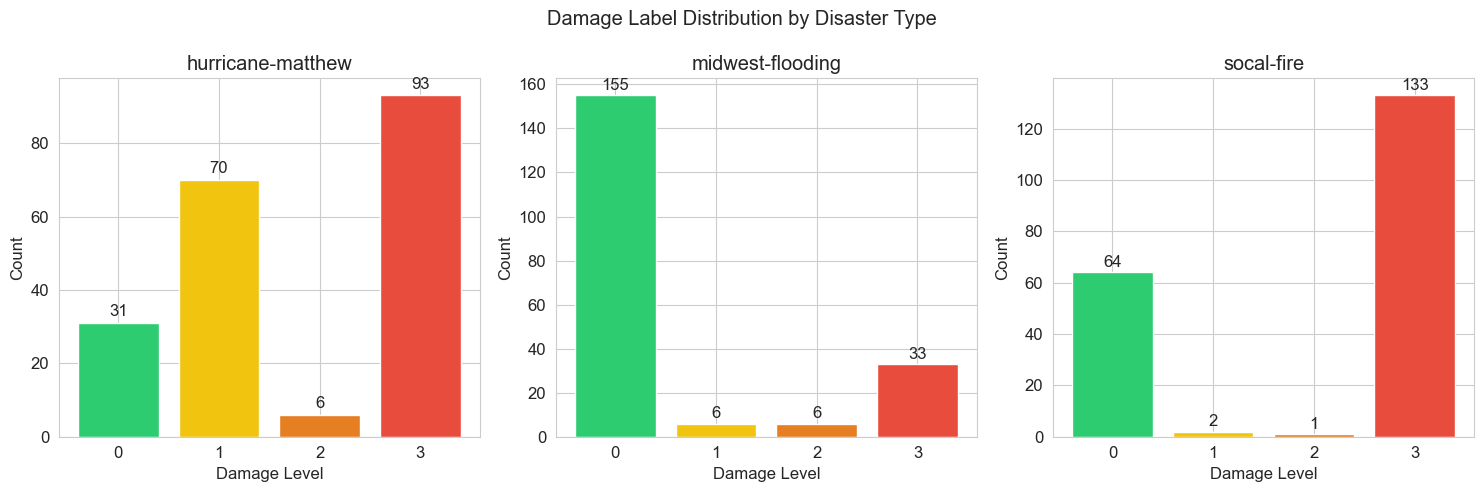

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, disaster in enumerate(disaster_list):
    labels = data[disaster]['labels']
    counts = [sum(labels == i) for i in range(4)]
    colors = [DAMAGE_COLORS[i] for i in range(4)]
    
    bars = axes[idx].bar(range(4), counts, color=colors)
    
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      str(count), ha='center', va='bottom')
    
    axes[idx].set_xticks(range(4))
    axes[idx].set_xticklabels(['0', '1', '2', '3'])
    axes[idx].set_xlabel('Damage Level')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{disaster}')

plt.suptitle('Damage Label Distribution by Disaster Type')
plt.tight_layout()
plt.show()

### Hurricane Matthew - Dataset

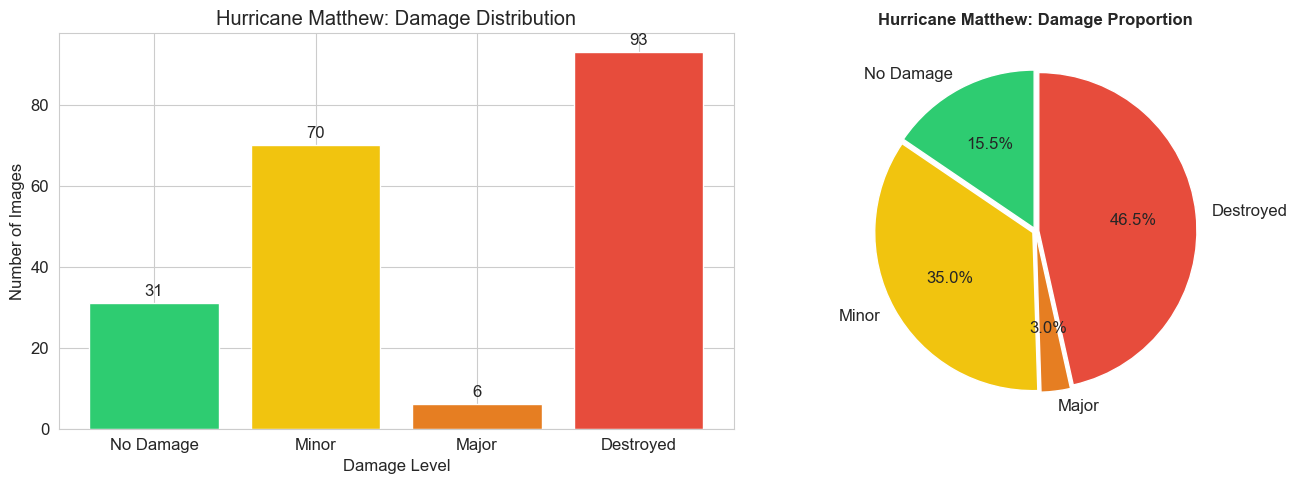

  - Class 0 (No Damage): 31 images (15.5%)
  - Class 1 (Minor): 70 images (35.0%)
  - Class 2 (Major): 6 images (3.0%)
  - Class 3 (Destroyed): 93 images (46.5%)


In [38]:
hurricane_labels = data['hurricane-matthew']['labels']
label_counts = Counter(hurricane_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [DAMAGE_COLORS[i] for i in range(4)]
counts = [label_counts.get(i, 0) for i in range(4)]
bars = axes[0].bar(range(4), counts, color=colors)

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha='center', va='bottom')

axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['No Damage', 'Minor', 'Major', 'Destroyed'])
axes[0].set_xlabel('Damage Level')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Hurricane Matthew: Damage Distribution')

axes[1].pie(counts, labels=['No Damage', 'Minor', 'Major', 'Destroyed'], 
           colors=colors, autopct='%1.1f%%', startangle=90,
           explode=(0.02, 0.02, 0.02, 0.02))
axes[1].set_title('Hurricane Matthew: Damage Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"  - Class 0 (No Damage): {counts[0]} images ({counts[0]/sum(counts)*100:.1f}%)")
print(f"  - Class 1 (Minor): {counts[1]} images ({counts[1]/sum(counts)*100:.1f}%)")
print(f"  - Class 2 (Major): {counts[2]} images ({counts[2]/sum(counts)*100:.1f}%)")
print(f"  - Class 3 (Destroyed): {counts[3]} images ({counts[3]/sum(counts)*100:.1f}%)")

**Modeling:**
- The hurricane dataset is reasonably balanced
- To handle class imbalance for major damage images, we will consider:
  - Class weights in loss functions
  - Stratified sampling during cross-validation
  - Oversampling minority classes

## Color Channel Analysis - RGB

In [39]:
def extract_rgb_means(image):
    """Extract mean R, G, B values from an image."""
    img = image.astype(np.float32)
    r_mean = img[:, :, 0].mean()
    g_mean = img[:, :, 1].mean()
    b_mean = img[:, :, 2].mean()
    return r_mean, g_mean, b_mean

rgb_data = []
for disaster in disaster_list:
    for i, img in enumerate(data[disaster]['images']):
        r, g, b = extract_rgb_means(img)
        rgb_data.append({
            'Disaster': disaster,
            'Label': data[disaster]['labels'][i],
            'R_mean': r,
            'G_mean': g,
            'B_mean': b
        })

rgb_df = pd.DataFrame(rgb_data)
print(f"Extracted RGB features for {len(rgb_df)} images")
display(rgb_df.head(10))

Extracted RGB features for 600 images


,Disaster,Label,R_mean,G_mean,B_mean
0,hurricane-matthew,1,80.946671,95.179169,64.224068
1,hurricane-matthew,3,82.295654,94.330956,75.778778
2,hurricane-matthew,1,96.923233,104.998306,71.095032
3,hurricane-matthew,3,80.765045,106.896721,83.332260
4,hurricane-matthew,1,75.076752,91.805740,71.761673
5,hurricane-matthew,3,76.883102,94.286087,67.425468
6,hurricane-matthew,3,72.111282,88.730934,58.597630
7,hurricane-matthew,1,89.609665,100.968773,68.317581
8,hurricane-matthew,1,127.602493,130.671417,98.298874
9,hurricane-matthew,1,83.819847,98.126984,61.716370


### Color Distribution by Disaster Type

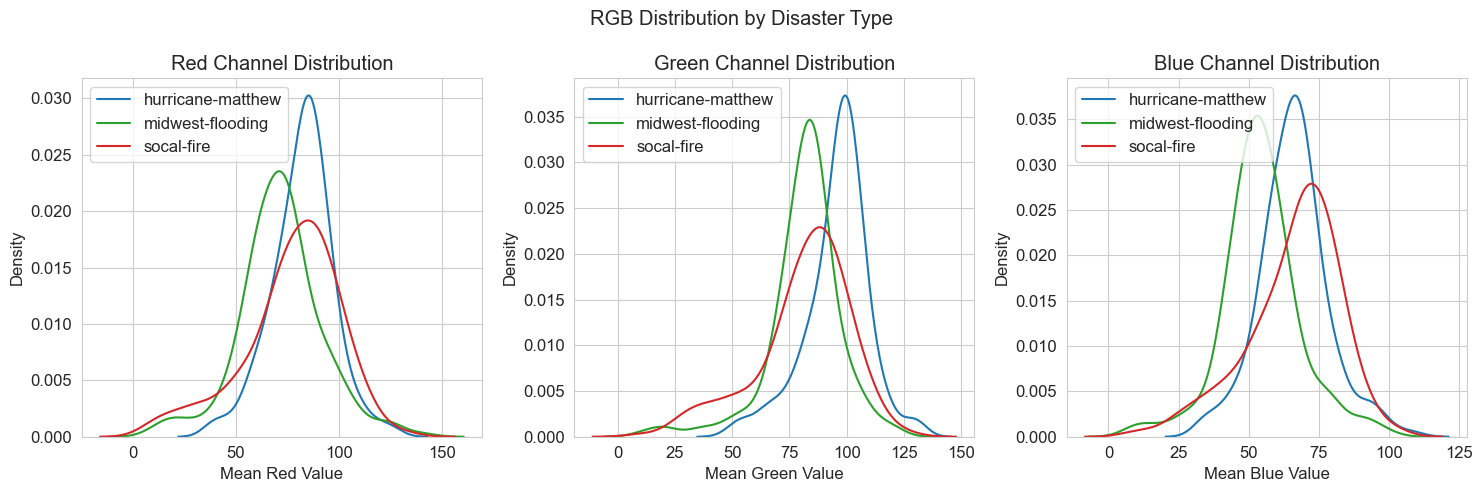

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['R_mean', 'G_mean', 'B_mean']
channel_names = ['Red', 'Green', 'Blue']

for idx, (channel, name) in enumerate(zip(channels, channel_names)):
    for disaster in disaster_list:
        subset = rgb_df[rgb_df['Disaster'] == disaster]
        sns.kdeplot(data=subset, x=channel, ax=axes[idx],
                   label=disaster, color=DISASTER_COLORS[disaster])
    axes[idx].set_title(f'{name} Channel Distribution')
    axes[idx].set_xlabel(f'Mean {name} Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('RGB Distribution by Disaster Type')
plt.tight_layout()
plt.show()

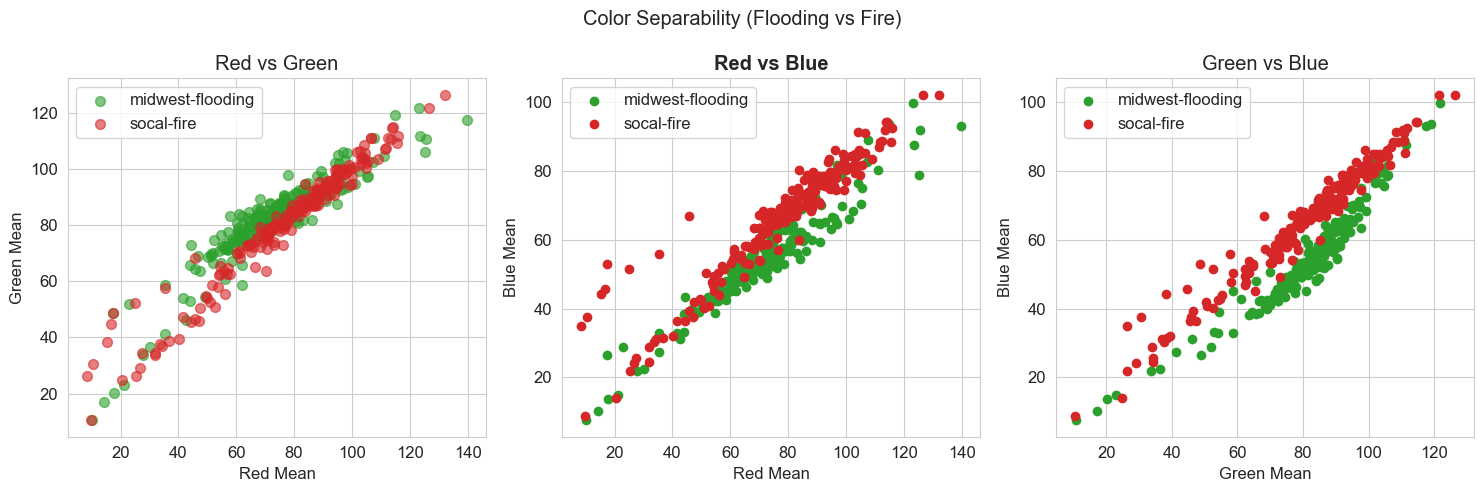

   - Flooding images have different color profiles (water, vegetation)
   - Fire images show different coloring (burnt areas, ash)


In [45]:
task_a_df = rgb_df[rgb_df['Disaster'].isin(['midwest-flooding', 'socal-fire'])]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for disaster in ['midwest-flooding', 'socal-fire']:
    subset = task_a_df[task_a_df['Disaster'] == disaster]
    axes[0].scatter(subset['R_mean'], subset['G_mean'], 
                   c=DISASTER_COLORS[disaster], label=disaster, alpha=0.6, s=50)
axes[0].set_xlabel('Red Mean')
axes[0].set_ylabel('Green Mean')
axes[0].set_title('Red vs Green')
axes[0].legend()

for disaster in ['midwest-flooding', 'socal-fire']:
    subset = task_a_df[task_a_df['Disaster'] == disaster]
    axes[1].scatter(subset['R_mean'], subset['B_mean'],
                   c=DISASTER_COLORS[disaster], label=disaster)
axes[1].set_xlabel('Red Mean')
axes[1].set_ylabel('Blue Mean')
axes[1].set_title('Red vs Blue', fontweight='bold')
axes[1].legend()

for disaster in ['midwest-flooding', 'socal-fire']:
    subset = task_a_df[task_a_df['Disaster'] == disaster]
    axes[2].scatter(subset['G_mean'], subset['B_mean'],
                   c=DISASTER_COLORS[disaster], label=disaster)
axes[2].set_xlabel('Green Mean')
axes[2].set_ylabel('Blue Mean')
axes[2].set_title('Green vs Blue')
axes[2].legend()

plt.suptitle('Color Separability (Flooding vs Fire)')
plt.tight_layout()
plt.show()

print("   - Flooding images have different color profiles (water, vegetation)")
print("   - Fire images show different coloring (burnt areas, ash)")

### Color Distribution by Damage Level

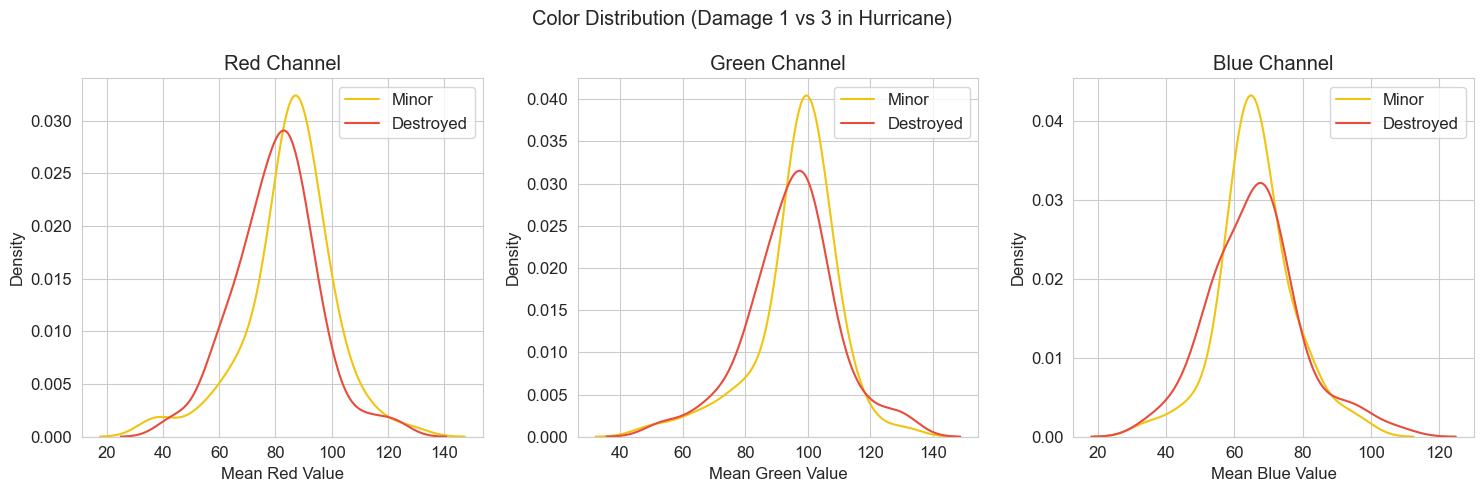

   - The distributions overlap
   - We need texture/edge features for better damage level discrimination


In [47]:
hurricane_df = rgb_df[rgb_df['Disaster'] == 'hurricane-matthew']
damage_1_3 = hurricane_df[hurricane_df['Label'].isin([1, 3])]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (channel, name) in enumerate(zip(channels, channel_names)):
    for label in [1, 3]:
        subset = damage_1_3[damage_1_3['Label'] == label]
        label_name = 'Minor' if label == 1 else 'Destroyed'
        sns.kdeplot(data=subset, x=channel, ax=axes[idx],
                   label=label_name, color=DAMAGE_COLORS[label])
    axes[idx].set_title(f'{name} Channel')
    axes[idx].set_xlabel(f'Mean {name} Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('Color Distribution (Damage 1 vs 3 in Hurricane)')
plt.tight_layout()
plt.show()

print("   - The distributions overlap")
print("   - We need texture/edge features for better damage level discrimination")


## Texture and Edge Features

- **Sobel Edge Detection**: Edges and boundaries in images
- **Gabor Filters**: Oriented texture patterns
- **Local Binary Patterns**: Enc


In [48]:
from starter_code.feature_utils import (
    get_sobel_features, 
    get_gabor_features, 
    generate_gabor_kernel, 
    get_local_binary_pattern
)

gabor_kernel = generate_gabor_kernel(theta=0, sigma=1.0, frequency=0.1)

In [49]:
texture_data = []
for disaster in disaster_list:
    for i, img in enumerate(data[disaster]['images']):
        sobel = get_sobel_features(img)
        gabor = get_gabor_features(img, gabor_kernel)
        lbp = get_local_binary_pattern(img)
        
        texture_data.append({
            'Disaster': disaster,
            'Label': data[disaster]['labels'][i],
            'Sobel_mean': sobel.mean(),
            'Gabor_mean': gabor.mean(),
            'LBP_mean': lbp.mean()
        })

texture_df = pd.DataFrame(texture_data)
display(texture_df.head(10))


,Disaster,Label,Sobel_mean,Gabor_mean,LBP_mean
0,hurricane-matthew,1,0.030430,0.289469,5.111531
1,hurricane-matthew,3,0.028032,0.291120,5.239828
2,hurricane-matthew,1,0.019601,0.324606,5.006725
3,hurricane-matthew,3,0.011486,0.320765,5.268412
4,hurricane-matthew,1,0.027774,0.279435,4.774286
5,hurricane-matthew,3,0.030874,0.285376,5.083194
6,hurricane-matthew,3,0.030704,0.267270,5.135558
7,hurricane-matthew,1,0.018835,0.309678,5.009421
8,hurricane-matthew,1,0.023706,0.411029,4.852576
9,hurricane-matthew,1,0.024462,0.297641,4.914368


### Texture Features by Disaster Type

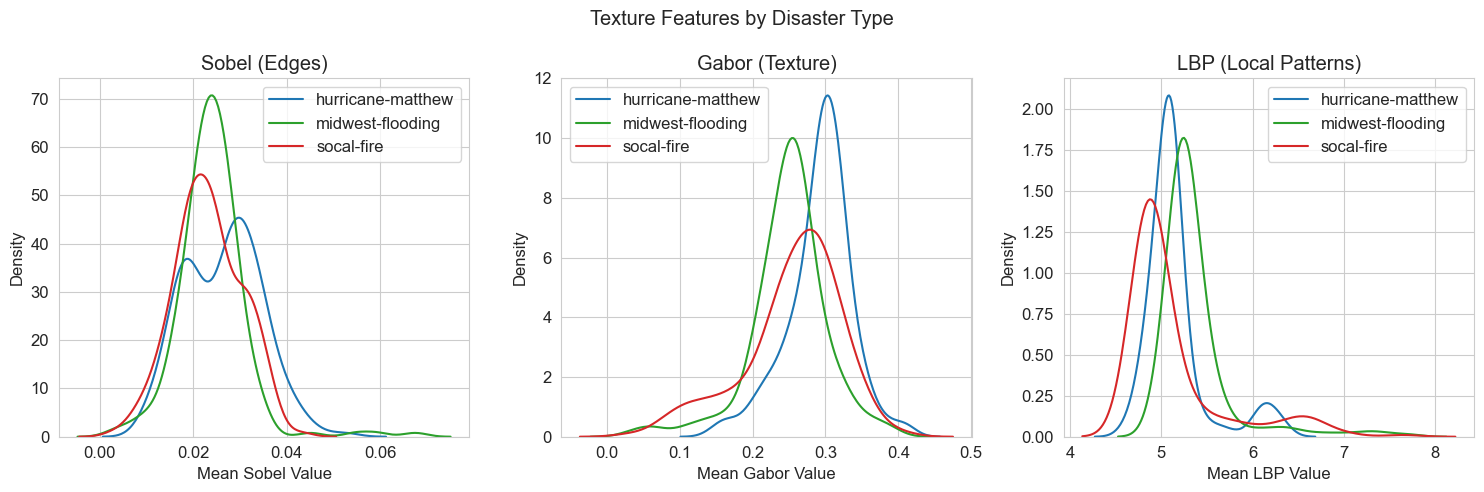

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['Sobel_mean', 'Gabor_mean', 'LBP_mean']
feature_names = ['Sobel (Edges)', 'Gabor (Texture)', 'LBP (Local Patterns)']

for idx, (feat, name) in enumerate(zip(features, feature_names)):
    for disaster in disaster_list:
        subset = texture_df[texture_df['Disaster'] == disaster]
        sns.kdeplot(data=subset, x=feat, ax=axes[idx],
                   label=disaster, color=DISASTER_COLORS[disaster])
    axes[idx].set_title(name)
    axes[idx].set_xlabel(f'Mean {name.split()[0]} Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('Texture Features by Disaster Type')
plt.tight_layout()
plt.show()

### Texture Features by Damage Level

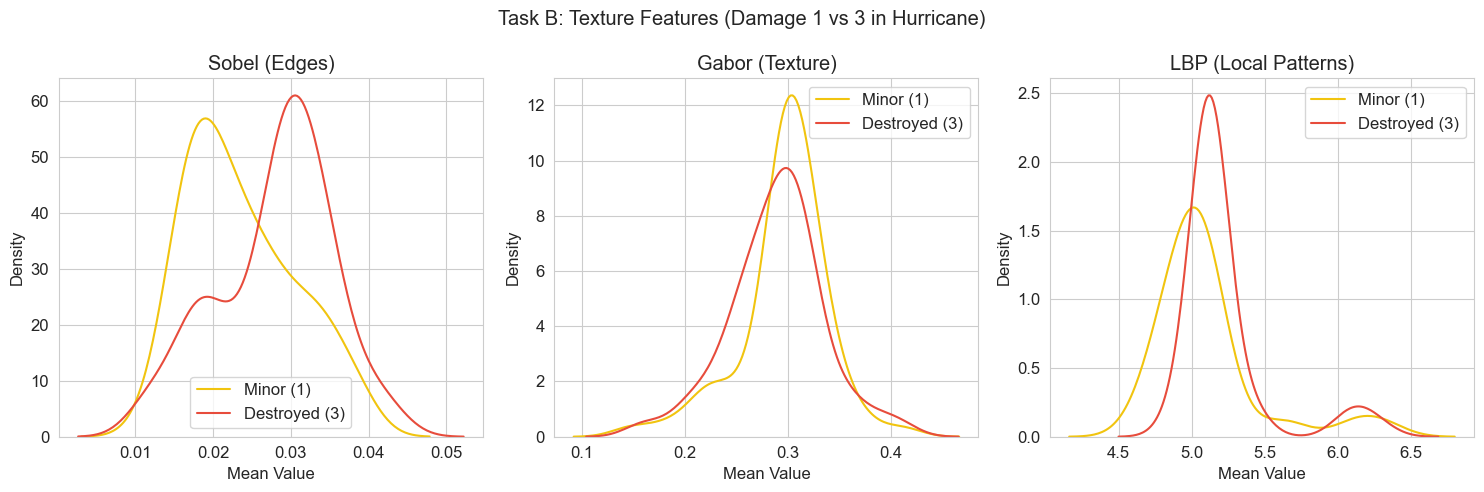

In [52]:
hurricane_texture = texture_df[texture_df['Disaster'] == 'hurricane-matthew']
damage_texture = hurricane_texture[hurricane_texture['Label'].isin([1, 3])]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (feat, name) in enumerate(zip(features, feature_names)):
    for label in [1, 3]:
        subset = damage_texture[damage_texture['Label'] == label]
        label_name = 'Minor (1)' if label == 1 else 'Destroyed (3)'
        sns.kdeplot(data=subset, x=feat, ax=axes[idx],
                   label=label_name, color=DAMAGE_COLORS[label])
    axes[idx].set_title(name)
    axes[idx].set_xlabel(f'Mean Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('Task B: Texture Features (Damage 1 vs 3 in Hurricane)')
plt.tight_layout()
plt.show()

/var/folders/qg/q9hfc49171q32729typh2j2r0000gn/T/ipykernel_42667/457084885.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['0', '1', '2', '3'], patch_artist=True)
/var/folders/qg/q9hfc49171q32729typh2j2r0000gn/T/ipykernel_42667/457084885.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['0', '1', '2', '3'], patch_artist=True)
/var/folders/qg/q9hfc49171q32729typh2j2r0000gn/T/ipykernel_42667/457084885.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['0', '1', '2', '3'], patch_artist=True)


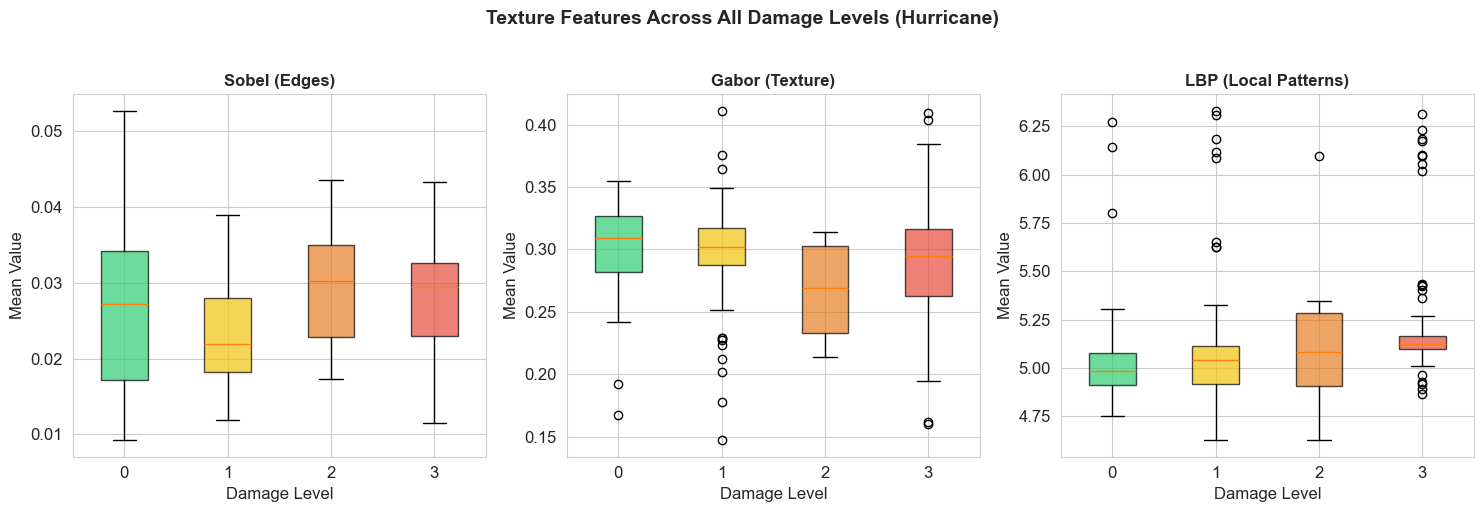

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (feat, name) in enumerate(zip(features, feature_names)):
    hurricane_all = texture_df[texture_df['Disaster'] == 'hurricane-matthew']
    
    box_data = [hurricane_all[hurricane_all['Label'] == label][feat].values for label in range(4)]
    bp = axes[idx].boxplot(box_data, labels=['0', '1', '2', '3'], patch_artist=True)
    
    for patch, label in zip(bp['boxes'], range(4)):
        patch.set_facecolor(DAMAGE_COLORS[label])
        patch.set_alpha(0.7)
    
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Damage Level')
    axes[idx].set_ylabel('Mean Value')

plt.suptitle('Texture Features Across All Damage Levels (Hurricane)')
plt.tight_layout()
plt.show()

## Sample Image Visualizations

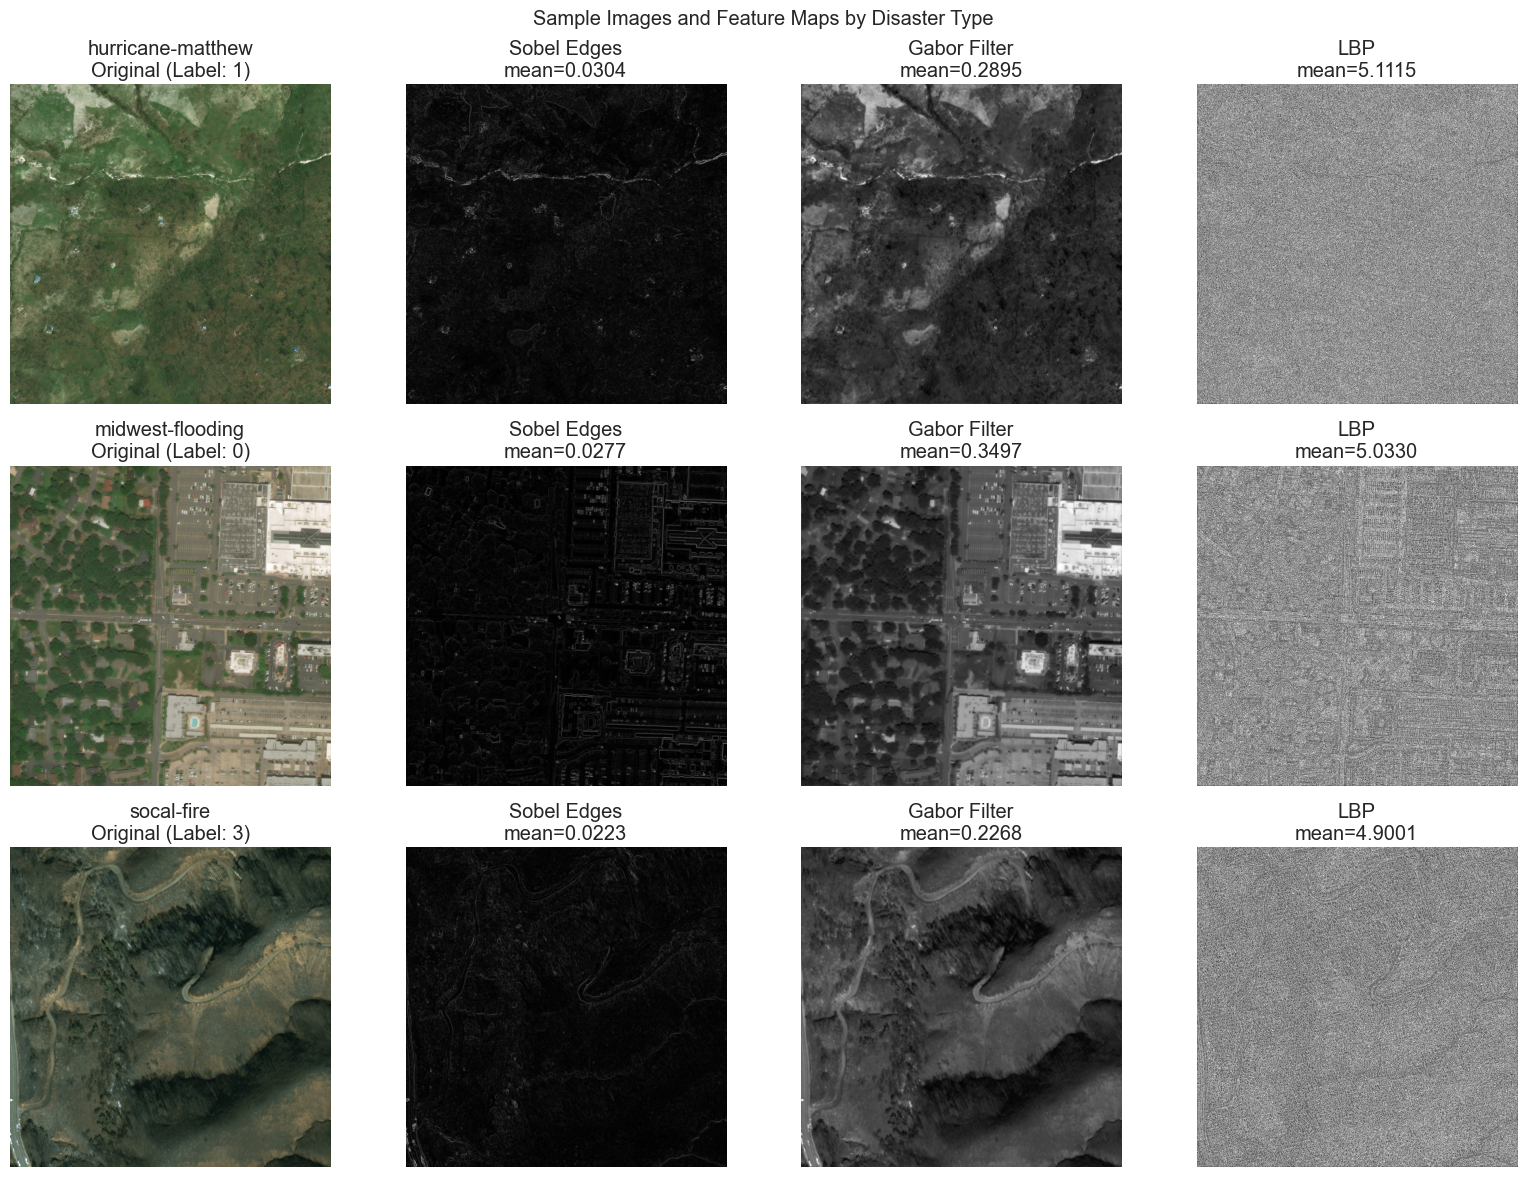

In [53]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, disaster in enumerate(disaster_list):
    img = data[disaster]['images'][0]
    label = data[disaster]['labels'][0]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'{disaster}\nOriginal (Label: {label})')
    axes[row, 0].axis('off')
    
    sobel = get_sobel_features(img)
    axes[row, 1].imshow(sobel, cmap='gray')
    axes[row, 1].set_title(f'Sobel Edges\nmean={sobel.mean():.4f}')
    axes[row, 1].axis('off')
    
    gabor = get_gabor_features(img, gabor_kernel)
    axes[row, 2].imshow(gabor, cmap='gray')
    axes[row, 2].set_title(f'Gabor Filter\nmean={gabor.mean():.4f}')
    axes[row, 2].axis('off')
    
    lbp = get_local_binary_pattern(img)
    axes[row, 3].imshow(lbp, cmap='gray')
    axes[row, 3].set_title(f'LBP\nmean={lbp.mean():.4f}')
    axes[row, 3].axis('off')

plt.suptitle('Sample Images and Feature Maps by Disaster Type')
plt.tight_layout()
plt.show()

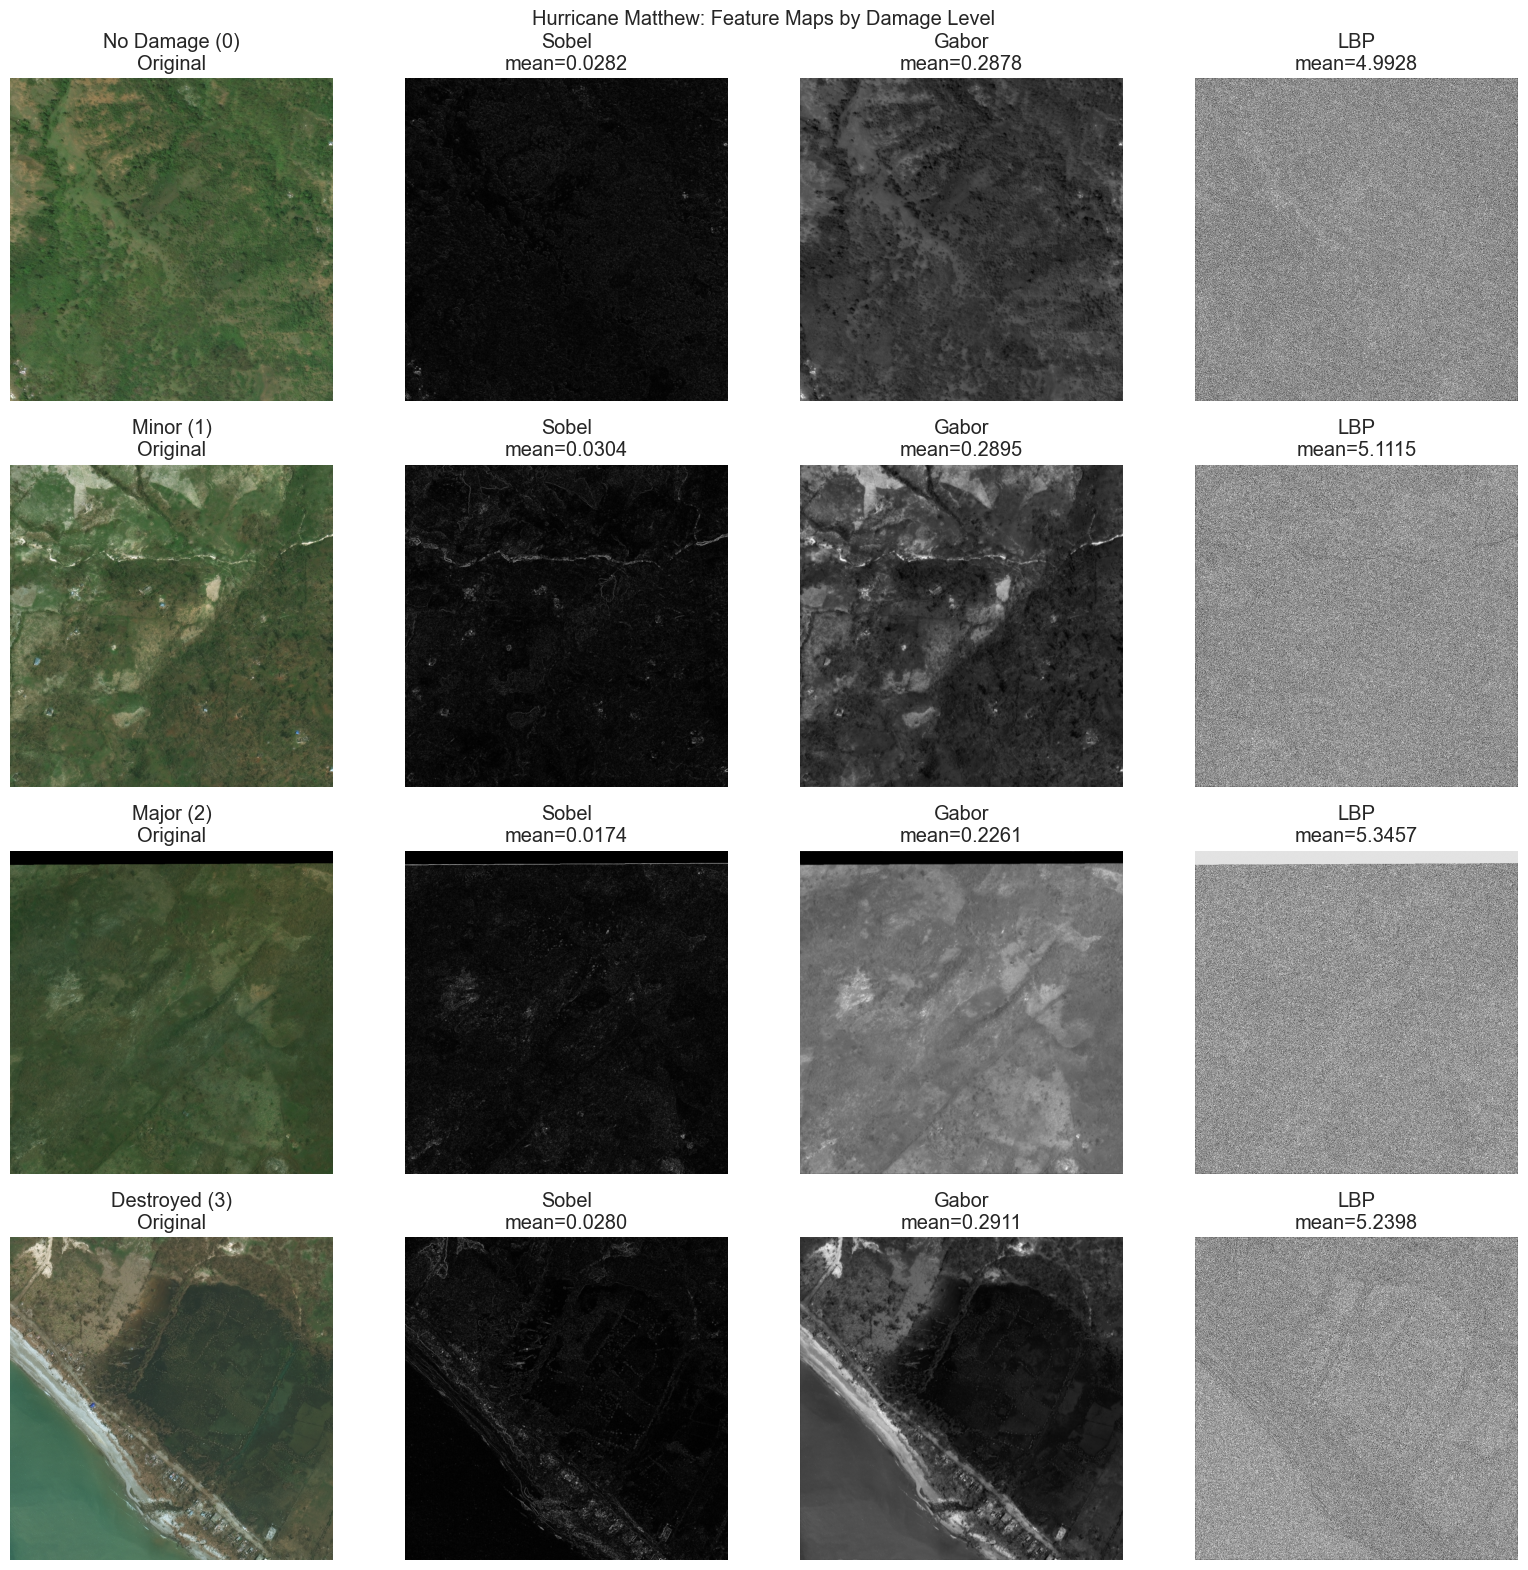

In [54]:
hurricane_images = data['hurricane-matthew']['images']
hurricane_labels = data['hurricane-matthew']['labels']

sample_indices = {}
for label in range(4):
    indices = np.where(hurricane_labels == label)[0]
    if len(indices) > 0:
        sample_indices[label] = indices[0]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

damage_names = ['No Damage (0)', 'Minor (1)', 'Major (2)', 'Destroyed (3)']

for row, label in enumerate(range(4)):
    if label in sample_indices:
        idx = sample_indices[label]
        img = hurricane_images[idx]
        
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'{damage_names[label]}\nOriginal')
        axes[row, 0].axis('off')
        
        sobel = get_sobel_features(img)
        axes[row, 1].imshow(sobel, cmap='gray')
        axes[row, 1].set_title(f'Sobel\nmean={sobel.mean():.4f}')
        axes[row, 1].axis('off')
        
        gabor = get_gabor_features(img, gabor_kernel)
        axes[row, 2].imshow(gabor, cmap='gray')
        axes[row, 2].set_title(f'Gabor\nmean={gabor.mean():.4f}')
        axes[row, 2].axis('off')
        
        lbp = get_local_binary_pattern(img)
        axes[row, 3].imshow(lbp, cmap='gray')
        axes[row, 3].set_title(f'LBP\nmean={lbp.mean():.4f}')
        axes[row, 3].axis('off')

plt.suptitle('Hurricane Matthew: Feature Maps by Damage Level')
plt.tight_layout()
plt.show()

### Visual Observations

**By Disaster Type:**
- **Flooding**: Images often show water, smoother textures, higher blue/green values
- **Fire**: Images show burnt areas, more texture variation, distinct color patterns
- **Hurricane**: Mix of structural damage patterns

**By Damage Level (Hurricane):**
- **No Damage**: Clear building structures
- **Minor**: Slight structural changes, similar edge patterns
- **Major**: More fragmented structures, increased edge complexity
- **Destroyed**: Highly fragmented, irregular edge patterns, debris visible

**Key Insight:** Edge and texture features capture structural damage better than color alone.

## Summary and Conclusions

### Key Dataset Properties

| Property | Value |
|----------|-------|
| Total Images | 600 (200 per disaster) |
| Image Size | Mostly 1024 × 1024 pixels |
| Color Channels | 3 (RGB) |
| Damage Levels | 4 (0=None, 1=Minor, 2=Major, 3=Destroyed) |
| Class Balance | Imbalanced for flooding/fire; more balanced for hurricane |


In [55]:
combined_df = pd.merge(
    rgb_df, 
    texture_df[['Disaster', 'Label', 'Sobel_mean', 'Gabor_mean', 'LBP_mean']], 
    on=['Disaster', 'Label'],
    how='inner'
)

print(f"Total samples: {len(combined_df)}")
print(f"Features available:")
print("  - Color: R_mean, G_mean, B_mean")
print("  - Texture: Sobel_mean, Gabor_mean, LBP_mean")
print(f"Feature statistics:")
display(combined_df.describe().round(4))


Total samples: 61522
Features available:
  - Color: R_mean, G_mean, B_mean
  - Texture: Sobel_mean, Gabor_mean, LBP_mean
Feature statistics:


,Label,R_mean,G_mean,B_mean,Sobel_mean,Gabor_mean,LBP_mean
count,61522.0000,61522.0000,61522.0000,61522.0000,61522.0000,61522.0000,61522.0000
mean,1.4201,75.2218,84.0450,60.8710,0.0239,0.2591,5.2337
std,1.4425,19.8824,18.1907,15.2064,0.0071,0.0580,0.4527
min,0.0000,8.4202,10.4479,7.5232,0.0028,0.0329,4.6256
25%,0.0000,64.3486,76.1496,51.5985,0.0193,0.2315,4.9628
50%,1.0000,76.1099,85.8202,60.7384,0.0237,0.2635,5.1476
75%,3.0000,87.9430,95.4628,70.7866,0.0281,0.2965,5.2956
max,3.0000,139.7661,131.1399,108.4864,0.0675,0.4110,7.6903


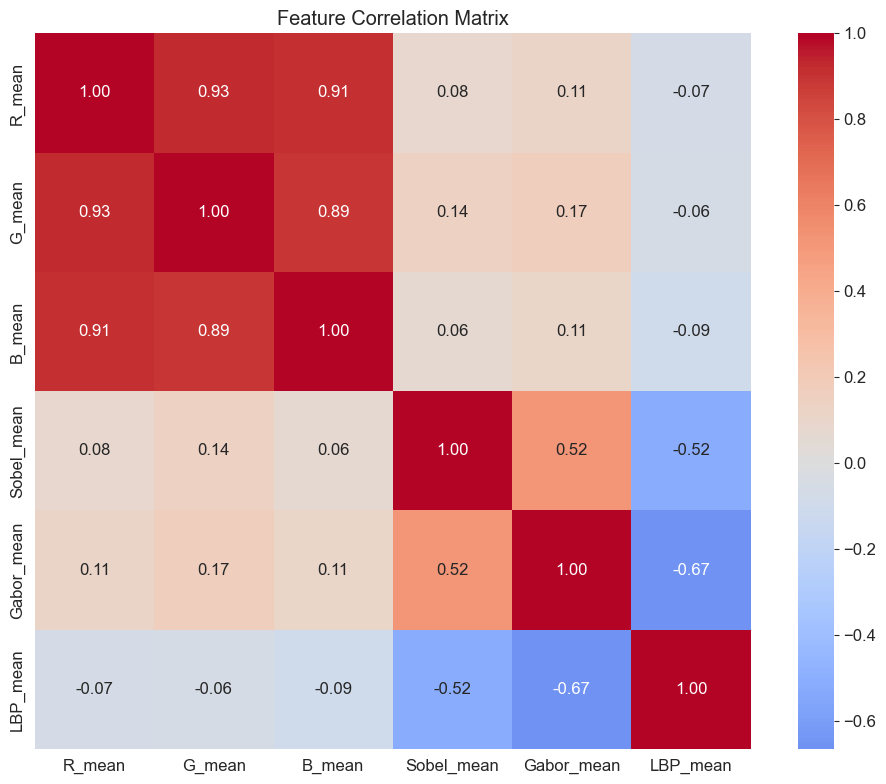

   - RGB channels are highly correlated with each other
   - Texture features provide independent information from color


In [57]:
feature_cols = ['R_mean', 'G_mean', 'B_mean', 'Sobel_mean', 'Gabor_mean', 'LBP_mean']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = combined_df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("   - RGB channels are highly correlated with each other")
print("   - Texture features provide independent information from color")

#### Task A: Disaster Type Classification (Flooding vs Fire)

| Aspect | Finding |
|--------|---------|
| Color Separability | **GOOD** - Distinct RGB distributions between flooding and fire |
| Texture Separability | **GOOD** - Different edge/texture patterns |
| Expected Difficulty | **LOW** - Should achieve high accuracy |
| Recommended Features | RGB means + Sobel/LBP features |

#### Task B: Damage Level Classification (Hurricane)

| Aspect | Finding |
|--------|---------|
| Color Separability | **LIMITED** - Significant overlap between damage levels |
| Texture Separability | **MODERATE** - Better separation than color |
| Class Balance | Relatively balanced across 4 classes |
| Expected Difficulty | **MODERATE to HIGH** - More challenging than Task A |
| Recommended Features | Prioritize texture features (Sobel, LBP) over color |
